#  Klasifikasi Ketan Putih dan Ketan Hitam
## MobileNetV2 (CNN Utama) + EfficientNetB0 (Feature Extractor) + KNN + K-Means

---

###  Arsitektur Sistem

| Komponen | Peran |
|---|---|
| **MobileNetV2** | Model CNN klasifikasi utama (supervised) |
| **EfficientNetB0** | Feature extractor untuk KNN & K-Means |
| **KNN (k=3)** | Klasifikasi supervised dari fitur EfficientNetB0 |
| **K-Means (FIXED)** | Clustering adaptif: PCA otomatis atau fallback Color Histogram |

###  Pipeline
| No | Tahap |
|---|---|
| 1 | Install & Import Library |
| 2 | Mount Google Drive |
| 3 | Setting Folder & Konstanta |
| 4 | Cek Data Raw |
| 5 | Preprocessing (Resize + Rename + HEIC→JPG) |
| 6 | Split Dataset (Train 70%, Val 20%, Test 10%) |
| 7 | Augmentasi Data Train |
| 8 | Gabung Train Asli + Augmented |
| 9 | MobileNetV2 — Build, Train, Evaluasi |
| 10 | EfficientNetB0 — Feature Extractor |
| 11 | KNN — Train & Evaluasi |
| 12 | K-Means (FIXED) — Cari PCA Terbaik / Fallback Color Histogram |
| 13 | Visualisasi t-SNE (Cluster vs Label Asli) |
| 14 | Perbandingan Akhir 3 Metode |

---
 **Pastikan Runtime menggunakan GPU: Runtime → Change runtime type → T4 GPU**

---


---
## BAGIAN 1 — SETUP & IMPORT

In [1]:
# ============================================================
# CELL 1: INSTALL LIBRARY HEIC
# ============================================================
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 31.0 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2: MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# CELL 3: IMPORT SEMUA LIBRARY
# ============================================================
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import pillow_heif
pillow_heif.register_heif_opener()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score, silhouette_score
)
from scipy.stats import mode

import tensorflow as tf
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array, array_to_img
)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print('TensorFlow version :', tf.__version__)
print('GPU tersedia        :', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version : 2.20.0
GPU tersedia        : True


In [4]:
# ============================================================
# CELL 4: SETTING FOLDER & KONSTANTA
# ============================================================
PROJECT_DIR        = '/content/drive/MyDrive/ProjectDeepLearning'
DATASET_DIR        = f'{PROJECT_DIR}/DATASET'
RAW_DIR            = f'{DATASET_DIR}/dataset_ketan_raw'
PREPROCESS_DIR     = f'{DATASET_DIR}/dataset_ketan_preprocessed'
FINAL_DIR          = f'{DATASET_DIR}/dataset_ketan_final'
AUGMENTED_DIR      = f'{DATASET_DIR}/dataset_ketan_augmented'
TRAIN_COMBINED_DIR = f'{DATASET_DIR}/dataset_ketan_train_combined'
HASIL_DIR          = f'{PROJECT_DIR}/hasil'

CLASSES    = ['ketan_putih', 'ketan_hitam']
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
EPOCHS     = 15

# Buat semua folder dulu paksa
for folder in [DATASET_DIR, HASIL_DIR, PREPROCESS_DIR]:
    os.makedirs(folder, exist_ok=True)
    print(f'Folder siap: {folder}')

Folder siap: /content/drive/MyDrive/ProjectDeepLearning/DATASET
Folder siap: /content/drive/MyDrive/ProjectDeepLearning/hasil
Folder siap: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_preprocessed


---
## BAGIAN 2 — PREPROCESSING DATA

In [5]:
# ============================================================
# CELL 5: CEK DATA RAW
# ============================================================
valid_ext = ('.jpg', '.jpeg', '.png', '.heic')

for cls in CLASSES:
    folder = os.path.join(RAW_DIR, cls)
    total  = 0
    print(f'\n[{cls}] Folder: {folder}')
    print(f'Ada? {os.path.exists(folder)}')
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            imgs = [f for f in files if f.lower().endswith(valid_ext)]
            if imgs:
                print(f'  Subfolder: {root} → {len(imgs)} gambar')
                total += len(imgs)
    print(f'  TOTAL: {total} gambar')


[ketan_putih] Folder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_putih
Ada? True
  Subfolder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_putih/tunggal → 206 gambar
  Subfolder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_putih/gabungan → 206 gambar
  TOTAL: 412 gambar

[ketan_hitam] Folder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_hitam
Ada? True
  Subfolder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_hitam/tunggal → 206 gambar
  Subfolder: /content/drive/MyDrive/ProjectDeepLearning/DATASET/dataset_ketan_raw/ketan_hitam/Gabungan → 206 gambar
  TOTAL: 412 gambar


In [6]:
# ============================================================
# CELL 6: PREPROCESSING — RESIZE 224x224 + RENAME + HEIC→JPG
# ============================================================
import time

if os.path.exists(PREPROCESS_DIR):
    shutil.rmtree(PREPROCESS_DIR)
os.makedirs(PREPROCESS_DIR, exist_ok=True)

preprocessed_log = []
gagal_log        = []

for cls in CLASSES:
    in_dir  = os.path.join(RAW_DIR, cls)
    out_dir = os.path.join(PREPROCESS_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)

    if not os.path.exists(in_dir):
        print(f' Folder tidak ditemukan: {in_dir}')
        continue

    prefix  = 'putih' if cls == 'ketan_putih' else 'hitam'
    counter = 1

    for root, dirs, files in os.walk(in_dir):
        for fname in files:
            if fname.lower().endswith(valid_ext):
                src  = os.path.join(root, fname)
                rl   = root.lower()
                tipe = 'tunggal' if 'tunggal' in rl else ('gabungan' if 'gabungan' in rl else 'unknown')

                # Retry sampai 3 kali untuk handle Drive timeout
                berhasil = False
                for attempt in range(3):
                    try:
                        img      = Image.open(src).convert('RGB')
                        img      = img.resize(IMG_SIZE)
                        new_name = f'{prefix}_{tipe}_{counter:04d}.jpg'
                        dst      = os.path.join(out_dir, new_name)
                        img.save(dst, 'JPEG', quality=95)
                        preprocessed_log.append({'filename': new_name, 'label': cls, 'tipe': tipe})
                        counter += 1
                        berhasil = True
                        break
                    except Exception as e:
                        if attempt < 2:
                            time.sleep(2)  # tunggu 2 detik lalu retry
                        else:
                            print(f' Gagal (3x): {fname} | {e}')
                            gagal_log.append({'filename': fname, 'error': str(e)})

os.makedirs(HASIL_DIR, exist_ok=True)  # pastikan folder hasil ada
df_pre = pd.DataFrame(preprocessed_log)
df_pre.to_csv(f'{HASIL_DIR}/log_preprocessing.csv', index=False)
print(f'\n Preprocessing selesai.')
print(f'   Berhasil : {len(df_pre)} gambar')
print(f'   Gagal    : {len(gagal_log)} gambar')
print(df_pre['label'].value_counts())


 Preprocessing selesai.
   Berhasil : 824 gambar
   Gagal    : 0 gambar
label
ketan_putih    412
ketan_hitam    412
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 7: CEK HASIL PREPROCESSING
# ============================================================
for cls in CLASSES:
    folder = os.path.join(PREPROCESS_DIR, cls)
    total  = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(folder) else 0
    print(f'{cls}: {total} gambar')

ketan_putih: 412 gambar
ketan_hitam: 412 gambar


---
## BAGIAN 3 — SPLIT DATASET

| Split | Proporsi | Fungsi |
|---|---|---|
| Train | 70% | Melatih model |
| Validation | 20% | Pantau performa saat training |
| Test | 10% | Evaluasi akhir — **tidak pernah dilihat model saat training** |

In [8]:
# ============================================================
# CELL 8: SPLIT DATASET 70/20/10
# ============================================================
if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

for split in ['train', 'validation', 'test']:
    for cls in CLASSES:
        os.makedirs(os.path.join(FINAL_DIR, split, cls), exist_ok=True)

split_log = []

for cls in CLASSES:
    cls_dir = os.path.join(PREPROCESS_DIR, cls)
    images  = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)

    train_f, temp_f = train_test_split(images, test_size=0.30, random_state=42)
    val_f,   test_f = train_test_split(temp_f, test_size=1/3,  random_state=42)

    for split, files in [('train', train_f), ('validation', val_f), ('test', test_f)]:
        for f in files:
            shutil.copy(os.path.join(cls_dir, f), os.path.join(FINAL_DIR, split, cls, f))
            split_log.append({'filename': f, 'label': cls, 'split': split})

df_split = pd.DataFrame(split_log)
df_split.to_csv(f'{HASIL_DIR}/log_split.csv', index=False)

print(f"{'Split':<12} {'ketan_putih':>14} {'ketan_hitam':>14} {'Total':>8}")
print('-' * 52)
for split in ['train', 'validation', 'test']:
    totals = []
    for cls in CLASSES:
        folder = os.path.join(FINAL_DIR, split, cls)
        totals.append(len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(folder) else 0)
    print(f"{split:<12} {totals[0]:>14} {totals[1]:>14} {sum(totals):>8}")

Split           ketan_putih    ketan_hitam    Total
----------------------------------------------------
train                   288            288      576
validation               82             82      164
test                     42             42       84


---
## BAGIAN 4 — AUGMENTASI DATA

Augmentasi hanya dilakukan pada **data train** untuk memperbanyak variasi.

Teknik: rotasi, zoom, horizontal flip, brightness adjustment.

In [9]:
# ============================================================
# CELL 9: AUGMENTASI DATA TRAIN
# ============================================================
AUG_TRAIN_DIR = f'{AUGMENTED_DIR}/train'

if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)

for cls in CLASSES:
    os.makedirs(os.path.join(AUG_TRAIN_DIR, cls), exist_ok=True)

aug_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

AUG_PER_IMAGE = 2
aug_log       = []

for cls in CLASSES:
    in_dir  = os.path.join(FINAL_DIR, 'train', cls)
    out_dir = os.path.join(AUG_TRAIN_DIR, cls)

    for fname in os.listdir(in_dir):
        if fname.lower().endswith(('.jpg','.jpeg','.png')):
            try:
                img   = load_img(os.path.join(in_dir, fname), target_size=IMG_SIZE)
                x     = np.expand_dims(img_to_array(img), axis=0)
                base  = os.path.splitext(fname)[0]
                it    = aug_datagen.flow(x, batch_size=1)
                for i in range(AUG_PER_IMAGE):
                    aug_img  = array_to_img(next(it)[0].astype('uint8'))
                    new_name = f'{base}_aug_{i+1}.jpg'
                    aug_img.save(os.path.join(out_dir, new_name), 'JPEG', quality=95)
                    aug_log.append({'filename': new_name, 'label': cls, 'source': fname})
            except Exception as e:
                print(f'Gagal: {fname} | {e}')

pd.DataFrame(aug_log).to_csv(f'{HASIL_DIR}/log_augmentasi.csv', index=False)
print(f'Augmentasi selesai. Total: {len(aug_log)} gambar baru')
for cls in CLASSES:
    folder = os.path.join(AUG_TRAIN_DIR, cls)
    print(f'  {cls}: {len(os.listdir(folder))} gambar')

Augmentasi selesai. Total: 1152 gambar baru
  ketan_putih: 576 gambar
  ketan_hitam: 576 gambar


In [10]:
# ============================================================
# CELL 10: GABUNG TRAIN ASLI + AUGMENTED
# ============================================================
if os.path.exists(TRAIN_COMBINED_DIR):
    shutil.rmtree(TRAIN_COMBINED_DIR)

for cls in CLASSES:
    out_dir = os.path.join(TRAIN_COMBINED_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)
    for src_dir in [os.path.join(FINAL_DIR, 'train', cls), os.path.join(AUG_TRAIN_DIR, cls)]:
        for f in os.listdir(src_dir):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                shutil.copy(os.path.join(src_dir, f), os.path.join(out_dir, f))

print('TRAIN COMBINED:')
for cls in CLASSES:
    folder = os.path.join(TRAIN_COMBINED_DIR, cls)
    print(f'  {cls}: {len(os.listdir(folder))} gambar')

TRAIN COMBINED:
  ketan_putih: 864 gambar
  ketan_hitam: 864 gambar


---
## BAGIAN 5 — MOBILENETV2 (MODEL CNN UTAMA)

MobileNetV2 digunakan sebagai **model klasifikasi CNN utama** dengan pendekatan transfer learning dari ImageNet.

In [11]:
# ============================================================
# CELL 11: DATA GENERATOR MOBILENETV2
# ============================================================
train_dir = TRAIN_COMBINED_DIR
val_dir   = os.path.join(FINAL_DIR, 'validation')
test_dir  = os.path.join(FINAL_DIR, 'test')

train_gen_mn = ImageDataGenerator(preprocessing_function=mobilenet_preprocess).flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
val_gen_mn = ImageDataGenerator(preprocessing_function=mobilenet_preprocess).flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_gen_mn = ImageDataGenerator(preprocessing_function=mobilenet_preprocess).flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

CLASS_INDICES = train_gen_mn.class_indices
CLASS_NAMES   = list(CLASS_INDICES.keys())
print('Label kelas:', CLASS_INDICES)

Found 1728 images belonging to 2 classes.
Found 164 images belonging to 2 classes.
Found 84 images belonging to 2 classes.
Label kelas: {'ketan_hitam': 0, 'ketan_putih': 1}


In [12]:
# ============================================================
# CELL 12: BUILD MODEL MOBILENETV2
# ============================================================
mn_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mn_base.trainable = False

x  = GlobalAveragePooling2D()(mn_base.output)
x  = Dropout(0.3)(x)
x  = Dense(128, activation='relu')(x)
x  = Dropout(0.3)(x)
out= Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=mn_base.input, outputs=out)
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'Total params     : {mobilenet_model.count_params():,}')
print(f'Trainable params : {sum([tf.size(w).numpy() for w in mobilenet_model.trainable_weights]):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 2,422,081
Trainable params : 164,097


In [13]:
# ============================================================
# CELL 13: TRAINING MOBILENETV2 (15 EPOCH)
# ============================================================
history_mn = mobilenet_model.fit(
    train_gen_mn,
    validation_data=val_gen_mn,
    epochs=EPOCHS
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 51s 261ms/step - accuracy: 0.9797 - loss: 0.0454 - val_accuracy: 1.0000 - val_loss: 4.0096e-04
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 3.2601e-04
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 6.2542e-05
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 1.0000 - loss: 2.4588e-04 - val_accuracy: 1.0000 - val_loss: 5.3562e-05
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.9983 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 2.8132e-04
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.9959 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 4.2730e-05
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 1.0000 - loss: 2.4324e-04 - val_accuracy: 1.0000 - val_loss: 7.6718e-07
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - a

In [14]:
# ============================================================
# CELL 14: SIMPAN MODEL MOBILENETV2
# ============================================================
model_path = f'{HASIL_DIR}/model_mobilenetv2.keras'
mobilenet_model.save(model_path)
print('Model tersimpan di:', model_path)

Model tersimpan di: /content/drive/MyDrive/ProjectDeepLearning/hasil/model_mobilenetv2.keras


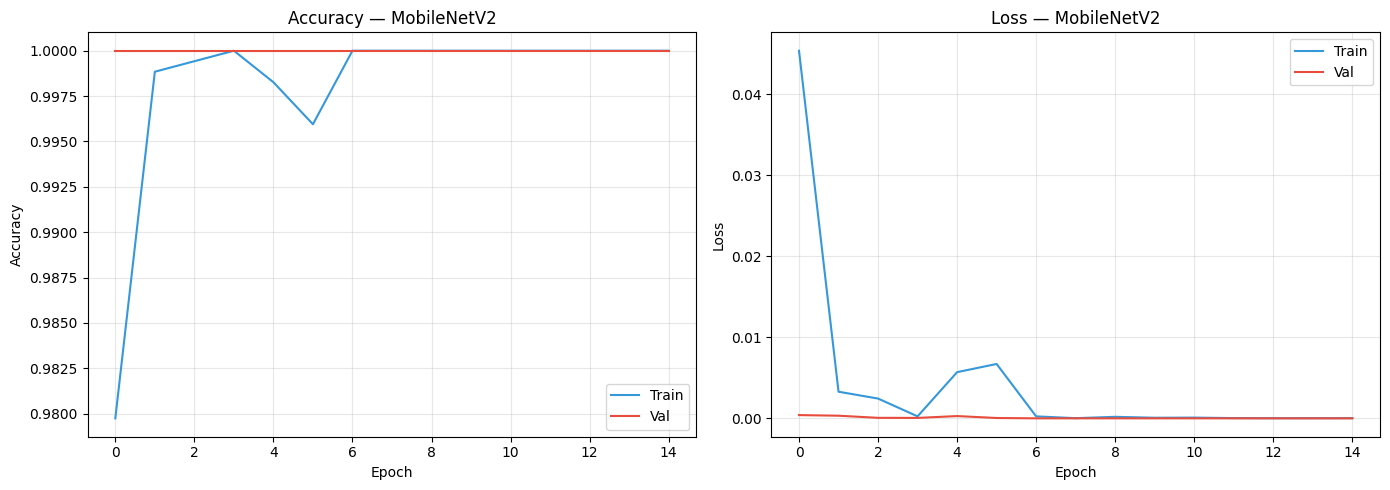

In [15]:
# ============================================================
# CELL 15: GRAFIK TRAINING MOBILENETV2
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mn.history['accuracy'],     label='Train', color='#3498db')
axes[0].plot(history_mn.history['val_accuracy'], label='Val',   color='#e74c3c')
axes[0].set_title('Accuracy — MobileNetV2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_mn.history['loss'],     label='Train', color='#3498db')
axes[1].plot(history_mn.history['val_loss'], label='Val',   color='#e74c3c')
axes[1].set_title('Loss — MobileNetV2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/grafik_mobilenetv2.png', dpi=150)
plt.show()

In [16]:
# ============================================================
# CELL 16: EVALUASI MOBILENETV2 PADA TEST SET
# ============================================================
y_true_mn       = test_gen_mn.classes
y_pred_mn       = (mobilenet_model.predict(test_gen_mn) > 0.5).astype(int).ravel()

mobilenet_acc       = accuracy_score(y_true_mn, y_pred_mn)
mobilenet_precision = precision_score(y_true_mn, y_pred_mn, zero_division=0)
mobilenet_recall    = recall_score(y_true_mn, y_pred_mn, zero_division=0)
mobilenet_f1        = f1_score(y_true_mn, y_pred_mn, zero_division=0)
cm_mn               = confusion_matrix(y_true_mn, y_pred_mn)

print(f'Akurasi MobileNetV2   : {mobilenet_acc:.4f}')
print(f'Precision MobileNetV2 : {mobilenet_precision:.4f}')
print(f'Recall MobileNetV2    : {mobilenet_recall:.4f}')
print(f'F1-Score MobileNetV2  : {mobilenet_f1:.4f}')
print('\nConfusion Matrix:')
print(cm_mn)
print('\nClassification Report:')
print(classification_report(y_true_mn, y_pred_mn, target_names=CLASS_NAMES))

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Akurasi MobileNetV2   : 1.0000
Precision MobileNetV2 : 1.0000
Recall MobileNetV2    : 1.0000
F1-Score MobileNetV2  : 1.0000

Confusion Matrix:
[[42  0]
 [ 0 42]]

Classification Report:
              precision    recall  f1-score   support

 ketan_hitam       1.00      1.00      1.00        42
 ketan_putih       1.00      1.00      1.00        42

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



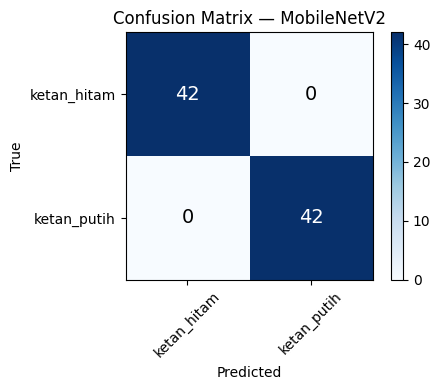

In [17]:
# ============================================================
# CELL 17: PLOT CONFUSION MATRIX MOBILENETV2
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_mn, cmap='Blues')
plt.colorbar(im)
ax.set_title('Confusion Matrix — MobileNetV2')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_mn[i,j], ha='center', va='center',
                color='white' if cm_mn[i,j] > cm_mn.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/cm_mobilenetv2.png', dpi=150)
plt.show()

---
## BAGIAN 6 — EFFICIENTNETB0 SEBAGAI FEATURE EXTRACTOR

EfficientNetB0 digunakan **hanya sebagai feature extractor** untuk menghasilkan representasi fitur yang akan digunakan oleh KNN dan K-Means.

> EfficientNetB0 dipilih karena menghasilkan distribusi fitur yang lebih baik untuk clustering dibandingkan MobileNetV2.

In [18]:
# ============================================================
# CELL 18: BUILD EFFICIENTNETB0 FEATURE EXTRACTOR
# ============================================================
en_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
en_base.trainable = False

efficientnet_extractor = Model(
    inputs=en_base.input,
    outputs=GlobalAveragePooling2D()(en_base.output)
)

print('EfficientNetB0 feature extractor siap.')
print('Output shape: (None, 1280)')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 feature extractor siap.
Output shape: (None, 1280)


In [19]:
# ============================================================
# CELL 19: FUNGSI EKSTRAKSI FITUR EFFICIENTNETB0
# ============================================================
def extract_features_efficientnet(directory):
    gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess).flow_from_directory(
        directory, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=False
    )
    features      = efficientnet_extractor.predict(gen)
    labels        = gen.classes
    filenames     = gen.filenames
    class_indices = gen.class_indices
    return features, labels, filenames, class_indices

In [20]:
# ============================================================
# CELL 20: EKSTRAKSI FITUR UNTUK KNN (TRAIN & TEST)
# ============================================================
print('Mengekstraksi fitur train (EfficientNetB0)...')
X_train_en, y_train_en, _, _ = extract_features_efficientnet(TRAIN_COMBINED_DIR)

print('Mengekstraksi fitur test (EfficientNetB0)...')
X_test_en, y_test_en, _, _   = extract_features_efficientnet(test_dir)

print(f'Shape fitur train : {X_train_en.shape}')
print(f'Shape fitur test  : {X_test_en.shape}')

Mengekstraksi fitur train (EfficientNetB0)...
Found 1728 images belonging to 2 classes.
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step
Mengekstraksi fitur test (EfficientNetB0)...
Found 84 images belonging to 2 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Shape fitur train : (1728, 1280)
Shape fitur test  : (84, 1280)


In [21]:
# ============================================================
# CELL 21: EKSTRAKSI FITUR SELURUH DATASET (UNTUK K-MEANS)
# K-Means pakai semua data karena unsupervised
# ============================================================
print('Mengekstraksi fitur seluruh dataset (EfficientNetB0)...')
X_all_en, y_all_en, _, class_indices_all = extract_features_efficientnet(PREPROCESS_DIR)

print(f'Shape semua fitur : {X_all_en.shape}')
print(f'Jumlah data       : {len(y_all_en)}')
print(f'Label kelas       : {class_indices_all}')

Mengekstraksi fitur seluruh dataset (EfficientNetB0)...
Found 824 images belonging to 2 classes.
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 286ms/step
Shape semua fitur : (824, 1280)
Jumlah data       : 824
Label kelas       : {'ketan_hitam': 0, 'ketan_putih': 1}


---
## BAGIAN 7 — KNN (K-Nearest Neighbor)

KNN menggunakan fitur dari **EfficientNetB0** sebagai input klasifikasi.

In [22]:
# ============================================================
# CELL 22: TRAINING KNN (k=3)
# ============================================================
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_en, y_train_en)
print('KNN training selesai. Fitur dari: EfficientNetB0')

KNN training selesai. Fitur dari: EfficientNetB0


In [23]:
# ============================================================
# CELL 23: EVALUASI KNN
# ============================================================
y_pred_knn    = knn.predict(X_test_en)
knn_acc       = accuracy_score(y_test_en, y_pred_knn)
knn_precision = precision_score(y_test_en, y_pred_knn, zero_division=0)
knn_recall    = recall_score(y_test_en, y_pred_knn, zero_division=0)
knn_f1        = f1_score(y_test_en, y_pred_knn, zero_division=0)
cm_knn        = confusion_matrix(y_test_en, y_pred_knn)

print(f'Akurasi KNN   : {knn_acc:.4f}')
print(f'Precision KNN : {knn_precision:.4f}')
print(f'Recall KNN    : {knn_recall:.4f}')
print(f'F1-Score KNN  : {knn_f1:.4f}')
print('\nConfusion Matrix KNN:')
print(cm_knn)
print('\nClassification Report KNN:')
print(classification_report(y_test_en, y_pred_knn, target_names=CLASS_NAMES, zero_division=0))

Akurasi KNN   : 1.0000
Precision KNN : 1.0000
Recall KNN    : 1.0000
F1-Score KNN  : 1.0000

Confusion Matrix KNN:
[[42  0]
 [ 0 42]]

Classification Report KNN:
              precision    recall  f1-score   support

 ketan_hitam       1.00      1.00      1.00        42
 ketan_putih       1.00      1.00      1.00        42

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



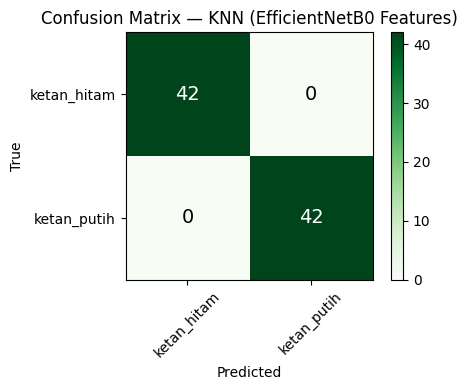

In [24]:
# ============================================================
# CELL 24: PLOT CONFUSION MATRIX KNN
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_knn, cmap='Greens')
plt.colorbar(im)
ax.set_title('Confusion Matrix — KNN (EfficientNetB0 Features)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_knn[i,j], ha='center', va='center',
                color='white' if cm_knn[i,j] > cm_knn.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/cm_knn.png', dpi=150)
plt.show()

---
## BAGIAN 8 — K-MEANS CLUSTERING (FIXED)

K-Means menggunakan fitur dari **EfficientNetB0** dengan strategi adaptif:
- **Coba berbagai PCA** (5, 10, 20, 30, 50, 100 komponen) → pilih yang terbaik
- **Jika Silhouette ≥ 0.3** → pakai PCA terbaik
- **Jika Silhouette < 0.3** → otomatis fallback ke **Color Histogram** (lebih cocok karena perbedaan ketan putih vs hitam = perbedaan warna)


---
## STEP 1 — Cari n_components PCA Terbaik

In [25]:
# ============================================================
# FIX CELL 1: CEK BERBAGAI n_components PCA
# Jalankan ini dulu sebelum memilih n_components final
# ============================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Normalisasi fitur EfficientNetB0
scaler       = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all_en)

print('=' * 65)
print('   PENCARIAN n_components PCA TERBAIK UNTUK K-MEANS')
print('=' * 65)
print(f"{'PCA':>6} {'Silhouette':>12} {'Cluster 0':>12} {'Cluster 1':>12} {'Seimbang?':>10}")
print('-' * 65)

hasil_pca = []
for n in [5, 10, 20, 30, 50, 100]:
    try:
        pca_t    = PCA(n_components=n, random_state=42)
        X_t      = pca_t.fit_transform(X_all_scaled)
        km_t     = KMeans(n_clusters=2, random_state=42, n_init=20)
        lbl_t    = km_t.fit_predict(X_t)
        sil_t    = silhouette_score(X_t, lbl_t)
        unique, counts = np.unique(lbl_t, return_counts=True)
        c0, c1   = counts[0], counts[1]
        seimbang = '✅' if min(c0,c1) > 50 else '❌'
        print(f"{n:>6} {sil_t:>12.4f} {c0:>12} {c1:>12} {seimbang:>10}")
        hasil_pca.append({'n': n, 'sil': sil_t, 'c0': c0, 'c1': c1, 'seimbang': min(c0,c1) > 50})
    except Exception as e:
        print(f"{n:>6} ERROR: {e}")

print('=' * 65)

valid_pca = [h for h in hasil_pca if h['seimbang']]
if valid_pca:
    best_pca = max(valid_pca, key=lambda x: x['sil'])
    print(f"\n PCA terbaik: {best_pca['n']} komponen (Silhouette: {best_pca['sil']:.4f})")
    BEST_N_PCA = best_pca['n']
    BEST_SIL   = best_pca['sil']
else:
    print('\n Semua PCA menghasilkan cluster tidak seimbang!')
    print('   → Akan otomatis fallback ke Color Histogram')
    BEST_N_PCA = None
    BEST_SIL   = 0

   PENCARIAN n_components PCA TERBAIK UNTUK K-MEANS
   PCA   Silhouette    Cluster 0    Cluster 1  Seimbang?
-----------------------------------------------------------------
     5       0.4852          412          412          ✅
    10       0.3792          412          412          ✅
    20       0.3199          412          412          ✅
    30       0.2968          412          412          ✅
    50       0.2750          412          412          ✅
   100       0.2541          412          412          ✅

 PCA terbaik: 5 komponen (Silhouette: 0.4852)


---
## STEP 2 — K-Means dengan PCA Terbaik
Kalau Silhouette ≥ 0.3 → pakai PCA. Kalau < 0.3 → fallback ke Color Histogram.

In [26]:
# ============================================================
# FIX CELL 2: K-MEANS DENGAN PCA TERBAIK
# ============================================================
from scipy.stats import mode
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

PAKAI_PCA = BEST_N_PCA is not None and BEST_SIL >= 0.30

if PAKAI_PCA:
    print(f'✅ Menggunakan PCA {BEST_N_PCA} komponen (Silhouette: {BEST_SIL:.4f})')
    pca_final    = PCA(n_components=BEST_N_PCA, random_state=42)
    X_kmeans     = pca_final.fit_transform(X_all_scaled)
    y_kmeans_true= y_all_en
    metode_label = f'K-Means + PCA ({BEST_N_PCA} komponen)'
else:
    print('⚠️ PCA kurang optimal → Fallback ke Color Histogram')
    PAKAI_PCA = False

if PAKAI_PCA:
    kmeans         = KMeans(n_clusters=2, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_kmeans)
    sil_score_km   = silhouette_score(X_kmeans, cluster_labels)

    mapped_labels = np.zeros_like(cluster_labels)
    for cluster in np.unique(cluster_labels):
        mask           = cluster_labels == cluster
        majority_label = mode(y_kmeans_true[mask], keepdims=True).mode[0]
        mapped_labels[mask] = majority_label

    kmeans_acc       = accuracy_score(y_kmeans_true, mapped_labels)
    kmeans_precision = precision_score(y_kmeans_true, mapped_labels, zero_division=0)
    kmeans_recall    = recall_score(y_kmeans_true, mapped_labels, zero_division=0)
    kmeans_f1        = f1_score(y_kmeans_true, mapped_labels, zero_division=0)
    cm_km            = confusion_matrix(y_kmeans_true, mapped_labels)

    print(f'\nSilhouette Score : {sil_score_km:.4f}')
    print(f'Akurasi K-Means  : {kmeans_acc:.4f}')
    print(f'Precision        : {kmeans_precision:.4f}')
    print(f'Recall           : {kmeans_recall:.4f}')
    print(f'F1-Score         : {kmeans_f1:.4f}')
    print('\nConfusion Matrix:')
    print(cm_km)
    print('\nClassification Report:')
    print(classification_report(y_kmeans_true, mapped_labels,
          target_names=CLASS_NAMES, zero_division=0))

✅ Menggunakan PCA 5 komponen (Silhouette: 0.4852)

Silhouette Score : 0.4852
Akurasi K-Means  : 0.5000
Precision        : 0.0000
Recall           : 0.0000
F1-Score         : 0.0000

Confusion Matrix:
[[412   0]
 [412   0]]

Classification Report:
              precision    recall  f1-score   support

 ketan_hitam       0.50      1.00      0.67       412
 ketan_putih       0.00      0.00      0.00       412

    accuracy                           0.50       824
   macro avg       0.25      0.50      0.33       824
weighted avg       0.25      0.50      0.33       824



---
## STEP 3 — Color Histogram (Fallback jika PCA gagal)

Color Histogram mengekstrak distribusi warna RGB dari setiap gambar.
Ini lebih cocok untuk ketan karena perbedaan utamanya adalah **warna** (putih vs hitam).

In [27]:
# ============================================================
# FIX CELL 3: EKSTRAKSI COLOR HISTOGRAM
# Dijalankan otomatis jika PCA kurang optimal
# ============================================================
import glob

def extract_color_histogram(img_path, bins=32):
    """Ekstrak histogram warna RGB dari gambar"""
    try:
        img  = Image.open(img_path).convert('RGB').resize((224, 224))
        img  = np.array(img)
        hist = []
        for c in range(3):  # R, G, B channel
            h, _ = np.histogram(img[:,:,c], bins=bins, range=(0, 256))
            hist.extend(h / h.sum())  # normalisasi
        return np.array(hist)  # shape: (96,) = 3 channel x 32 bins
    except:
        return None

if not PAKAI_PCA:
    print('Mengekstraksi Color Histogram dari seluruh dataset...')
    X_hist  = []
    y_hist  = []
    gagal   = 0

    for cls_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(PREPROCESS_DIR, cls)
        files   = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f'  [{cls}] {len(files)} gambar...')

        for fname in files:
            fpath = os.path.join(cls_dir, fname)
            hist  = extract_color_histogram(fpath)
            if hist is not None:
                X_hist.append(hist)
                y_hist.append(cls_idx)
            else:
                gagal += 1

    X_hist = np.array(X_hist)
    y_hist = np.array(y_hist)

    print(f'\nEkstraksi selesai.')
    print(f'Shape X_hist : {X_hist.shape}')
    print(f'Jumlah data  : {len(y_hist)} | Gagal: {gagal}')
else:
    print('PCA sudah optimal, Color Histogram tidak dijalankan.')

PCA sudah optimal, Color Histogram tidak dijalankan.


In [28]:
# ============================================================
# FIX CELL 4: K-MEANS DENGAN COLOR HISTOGRAM
# ============================================================
if not PAKAI_PCA:
    scaler_hist  = StandardScaler()
    X_hist_scaled= scaler_hist.fit_transform(X_hist)

    print('Cek PCA pada Color Histogram:')
    for n in [10, 20, 30, 50, 96]:
        if n >= X_hist_scaled.shape[1]:
            n = X_hist_scaled.shape[1] - 1
        pca_h    = PCA(n_components=n, random_state=42)
        X_h      = pca_h.fit_transform(X_hist_scaled)
        km_h     = KMeans(n_clusters=2, random_state=42, n_init=20)
        lbl_h    = km_h.fit_predict(X_h)
        sil_h    = silhouette_score(X_h, lbl_h)
        unique, counts = np.unique(lbl_h, return_counts=True)
        print(f'  PCA {n:>3} → Silhouette: {sil_h:.4f} | Cluster: {dict(zip(unique.tolist(), counts.tolist()))}')

    print('\nK-Means langsung dari Color Histogram (tanpa PCA):')
    kmeans_hist    = KMeans(n_clusters=2, random_state=42, n_init=20)
    cluster_hist   = kmeans_hist.fit_predict(X_hist_scaled)
    sil_score_km   = silhouette_score(X_hist_scaled, cluster_hist)

    print(f'Silhouette Score : {sil_score_km:.4f}')
    unique, counts = np.unique(cluster_hist, return_counts=True)
    print(f'Distribusi cluster: {dict(zip(unique.tolist(), counts.tolist()))}')

    mapped_hist = np.zeros_like(cluster_hist)
    for cluster in np.unique(cluster_hist):
        mask           = cluster_hist == cluster
        majority_label = mode(y_hist[mask], keepdims=True).mode[0]
        mapped_hist[mask] = majority_label

    kmeans_acc       = accuracy_score(y_hist, mapped_hist)
    kmeans_precision = precision_score(y_hist, mapped_hist, zero_division=0)
    kmeans_recall    = recall_score(y_hist, mapped_hist, zero_division=0)
    kmeans_f1        = f1_score(y_hist, mapped_hist, zero_division=0)
    cm_km            = confusion_matrix(y_hist, mapped_hist)
    cluster_labels   = cluster_hist
    y_kmeans_true    = y_hist
    metode_label     = 'K-Means + Color Histogram'

    print(f'\nAkurasi K-Means  : {kmeans_acc:.4f}')
    print(f'Precision        : {kmeans_precision:.4f}')
    print(f'Recall           : {kmeans_recall:.4f}')
    print(f'F1-Score         : {kmeans_f1:.4f}')
    print('\nConfusion Matrix:')
    print(cm_km)
    print('\nClassification Report:')
    print(classification_report(y_hist, mapped_hist,
          target_names=CLASS_NAMES, zero_division=0))
else:
    print('PCA sudah optimal, Color Histogram tidak dijalankan.')

PCA sudah optimal, Color Histogram tidak dijalankan.


---
## STEP 4 — Confusion Matrix K-Means

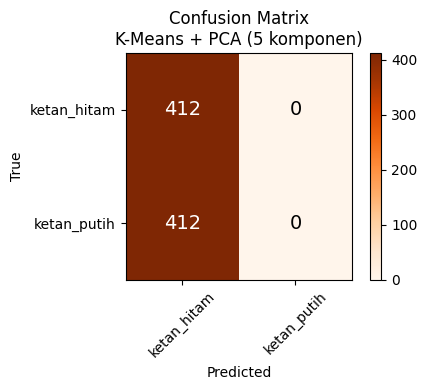

Confusion matrix tersimpan. Metode: K-Means + PCA (5 komponen)


In [29]:
# ============================================================
# FIX CELL 5: PLOT CONFUSION MATRIX K-MEANS
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_km, cmap='Oranges')
plt.colorbar(im)
ax.set_title(f'Confusion Matrix\n{metode_label}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_km[i,j], ha='center', va='center',
                color='white' if cm_km[i,j] > cm_km.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/cm_kmeans_fixed.png', dpi=150)
plt.show()
print(f'Confusion matrix tersimpan. Metode: {metode_label}')

---
## STEP 5 — Visualisasi t-SNE (Update)

Menjalankan t-SNE... (1-2 menit)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


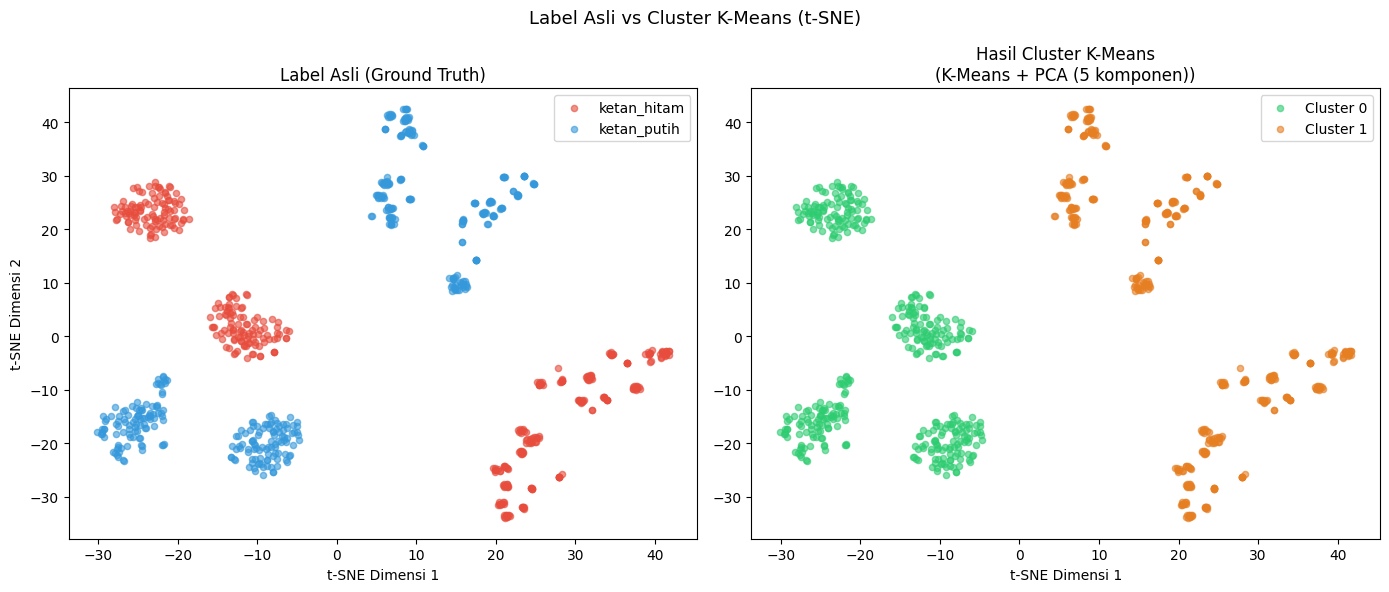

Visualisasi t-SNE tersimpan.


In [30]:
# ============================================================
# FIX CELL 6: VISUALISASI t-SNE DENGAN CLUSTER BARU
# ============================================================
from sklearn.manifold import TSNE

if PAKAI_PCA:
    X_for_tsne = X_all_scaled
    y_for_tsne = y_all_en
else:
    X_for_tsne = X_hist_scaled
    y_for_tsne = y_hist

print('Menjalankan t-SNE... (1-2 menit)')
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_for_tsne)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, color in zip([0, 1], ['#e74c3c', '#3498db']):
    mask = y_for_tsne == label
    axes[0].scatter(X_tsne[mask,0], X_tsne[mask,1],
                    c=color, label=CLASS_NAMES[label], alpha=0.6, s=20)
axes[0].set_title('Label Asli (Ground Truth)')
axes[0].set_xlabel('t-SNE Dimensi 1')
axes[0].set_ylabel('t-SNE Dimensi 2')
axes[0].legend()

for cluster, color in zip([0, 1], ['#2ecc71', '#e67e22']):
    mask = cluster_labels == cluster
    axes[1].scatter(X_tsne[mask,0], X_tsne[mask,1],
                    c=color, label=f'Cluster {cluster}', alpha=0.6, s=20)
axes[1].set_title(f'Hasil Cluster K-Means\n({metode_label})')
axes[1].set_xlabel('t-SNE Dimensi 1')
axes[1].legend()

plt.suptitle('Label Asli vs Cluster K-Means (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/tsne_kmeans_fixed.png', dpi=150)
plt.show()
print('Visualisasi t-SNE tersimpan.')

---
## BAGIAN 10 — PERBANDINGAN AKHIR KETIGA METODE

---
## STEP 6 — Update Tabel & Bar Chart Perbandingan

In [31]:
# ============================================================
# FIX CELL 7: TABEL PERBANDINGAN FINAL (UPDATED)
# ============================================================
# ============================================================
# TABEL 1: METODE SUPERVISED (MobileNetV2 dan KNN)
# Dievaluasi menggunakan accuracy, precision, recall, F1-score
# pada test set (data yang tidak pernah dilihat saat training)
# ============================================================
print('=' * 72)
print('         TABEL PERBANDINGAN METODE SUPERVISED')
print('=' * 72)
print(f"{'Metode':<28} {'Akurasi':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
print('-' * 72)
print(f"{'MobileNetV2 (CNN Utama)':<28} {mobilenet_acc:>9.4f} {mobilenet_precision:>10.4f} {mobilenet_recall:>8.4f} {mobilenet_f1:>10.4f}")
print(f"{'KNN (EfficientNetB0)':<28} {knn_acc:>9.4f} {knn_precision:>10.4f} {knn_recall:>8.4f} {knn_f1:>10.4f}")
print('=' * 72)
print('Catatan: Dievaluasi pada test set. Fitur KNN diekstrak dari EfficientNetB0.')
print()
print()
# ============================================================
# TABEL 2: METODE UNSUPERVISED (K-Means)
# K-Means tidak menggunakan label sehingga metrik evaluasinya
# berbeda. Metrik utama adalah Silhouette Score.
# ============================================================
print('=' * 72)
print('         EVALUASI K-MEANS (UNSUPERVISED)')
print('=' * 72)
print(f"{'Metode':<35} {'Silhouette Score':>16}")
print('-' * 72)
print(f"{metode_label:<35} {sil_score_km:>16.4f}")
print('=' * 72)
print()
print('Catatan:')
print('  K-Means adalah metode unsupervised yang tidak menggunakan label')
print('  kelas selama proses clustering. Oleh karena itu, metrik evaluasi')
print('  utama yang digunakan adalah Silhouette Score, bukan accuracy.')
print(f'  Nilai Silhouette Score {sil_score_km:.4f} menunjukkan bahwa cluster')
print('  yang terbentuk cukup terpisah, namun tidak berkorelasi langsung')
print('  dengan label kelas ketan putih dan ketan hitam. Hal ini')
print('  membuktikan bahwa informasi label sangat penting dalam klasifikasi')
print('  citra pangan berbasis deep learning.')

         TABEL PERBANDINGAN METODE SUPERVISED
Metode                         Akurasi  Precision   Recall   F1-Score
------------------------------------------------------------------------
MobileNetV2 (CNN Utama)         1.0000     1.0000   1.0000     1.0000
KNN (EfficientNetB0)            1.0000     1.0000   1.0000     1.0000
Catatan: Dievaluasi pada test set. Fitur KNN diekstrak dari EfficientNetB0.


         EVALUASI K-MEANS (UNSUPERVISED)
Metode                              Silhouette Score
------------------------------------------------------------------------
K-Means + PCA (5 komponen)                    0.4852

Catatan:
  K-Means adalah metode unsupervised yang tidak menggunakan label
  kelas selama proses clustering. Oleh karena itu, metrik evaluasi
  utama yang digunakan adalah Silhouette Score, bukan accuracy.
  Nilai Silhouette Score 0.4852 menunjukkan bahwa cluster
  yang terbentuk cukup terpisah, namun tidak berkorelasi langsung
  dengan label kelas ketan putih dan ketan

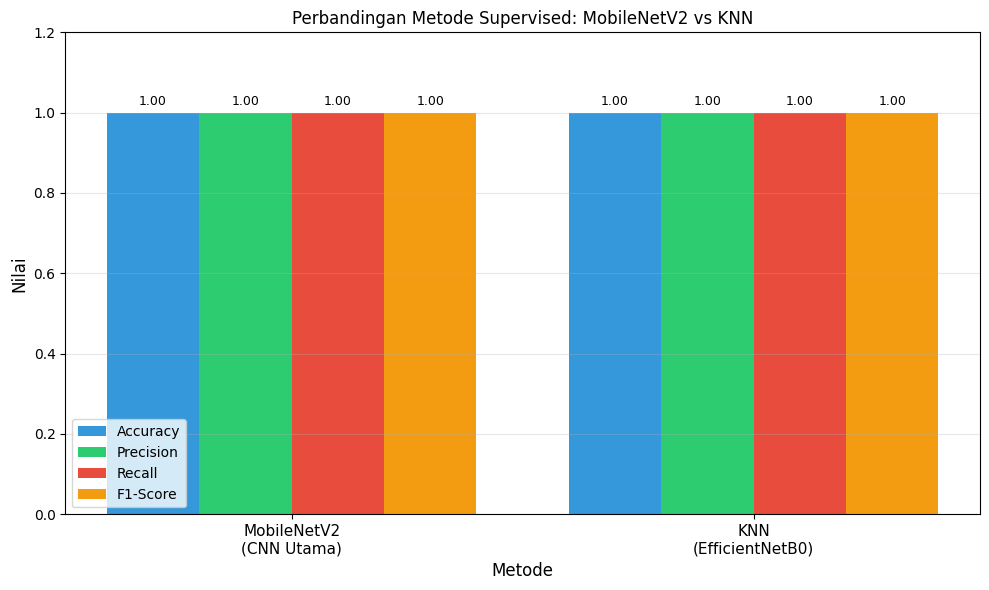

Grafik supervised tersimpan.


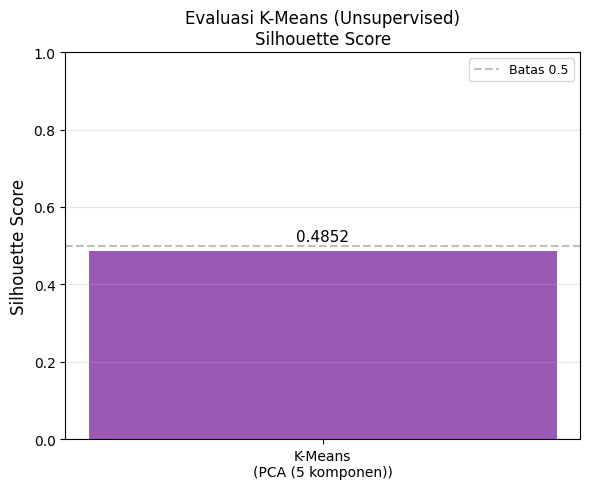

Grafik K-Means Silhouette Score tersimpan.


In [32]:
# ============================================================
# FIX CELL 8: BAR CHART PERBANDINGAN (UPDATED)
# ============================================================
# ============================================================
# GRAFIK 1: BAR CHART METODE SUPERVISED
# MobileNetV2 vs KNN
# ============================================================
metode_sup     = ['MobileNetV2\n(CNN Utama)', 'KNN\n(EfficientNetB0)']
akurasi_sup    = [mobilenet_acc,       knn_acc]
precision_sup  = [mobilenet_precision, knn_precision]
recall_sup     = [mobilenet_recall,    knn_recall]
f1_sup         = [mobilenet_f1,        knn_f1]

x     = np.arange(len(metode_sup))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
bars = [
    ax.bar(x - 1.5*width, akurasi_sup,   width, label='Accuracy',  color='#3498db'),
    ax.bar(x - 0.5*width, precision_sup, width, label='Precision', color='#2ecc71'),
    ax.bar(x + 0.5*width, recall_sup,    width, label='Recall',    color='#e74c3c'),
    ax.bar(x + 1.5*width, f1_sup,        width, label='F1-Score',  color='#f39c12'),
]
ax.set_xlabel('Metode', fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Perbandingan Metode Supervised: MobileNetV2 vs KNN', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metode_sup, fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar_group in bars:
    for bar in bar_group:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}',
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/grafik_supervised.png', dpi=150)
plt.show()
print('Grafik supervised tersimpan.')

# ============================================================
# GRAFIK 2: BAR CHART SILHOUETTE SCORE K-MEANS
# Disajikan terpisah karena metrik berbeda
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
bar = ax.bar(
    [f'K-Means\n({metode_label.replace("K-Means + ", "")})'],
    [sil_score_km],
    color='#9b59b6', width=0.3
)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Evaluasi K-Means (Unsupervised)\nSilhouette Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Batas 0.5')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for b in bar:
    ax.annotate(f'{b.get_height():.4f}',
        xy=(b.get_x() + b.get_width()/2, b.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/grafik_kmeans_silhouette.png', dpi=150)
plt.show()
print('Grafik K-Means Silhouette Score tersimpan.')

In [33]:
# ============================================================
# CELL TERAKHIR: SIMPAN HASIL FINAL KE CSV (DIPISAH)
# ============================================================

# Tabel 1: Metode Supervised
df_supervised = pd.DataFrame({
    'Metode'    : ['MobileNetV2', 'KNN'],
    'Accuracy'  : [mobilenet_acc,       knn_acc],
    'Precision' : [mobilenet_precision, knn_precision],
    'Recall'    : [mobilenet_recall,    knn_recall],
    'F1-Score'  : [mobilenet_f1,        knn_f1],
    'Paradigma' : ['Supervised', 'Supervised'],
    'Keterangan': [
        'CNN utama, transfer learning ImageNet, 15 epoch, test set',
        'Supervised, fitur dari EfficientNetB0, k=3, test set'
    ]
})

# Tabel 2: Metode Unsupervised
df_unsupervised = pd.DataFrame({
    'Metode'          : ['K-Means'],
    'Silhouette Score': [sil_score_km],
    'Paradigma'       : ['Unsupervised'],
    'Keterangan'      : [f'{metode_label}, seluruh dataset preprocessed']
})

csv_supervised   = f'{HASIL_DIR}/hasil_supervised.csv'
csv_unsupervised = f'{HASIL_DIR}/hasil_unsupervised_kmeans.csv'

df_supervised.to_csv(csv_supervised, index=False)
df_unsupervised.to_csv(csv_unsupervised, index=False)

print('File tersimpan:')
print(f'  {csv_supervised}')
print(f'  {csv_unsupervised}')
print()
print('HASIL METODE SUPERVISED:')
print(df_supervised.to_string(index=False))
print()
print('HASIL METODE UNSUPERVISED (Silhouette Score):')
print(df_unsupervised.to_string(index=False))

File tersimpan:
  /content/drive/MyDrive/ProjectDeepLearning/hasil/hasil_supervised.csv
  /content/drive/MyDrive/ProjectDeepLearning/hasil/hasil_unsupervised_kmeans.csv

HASIL METODE SUPERVISED:
     Metode  Accuracy  Precision  Recall  F1-Score  Paradigma                                                Keterangan
MobileNetV2       1.0        1.0     1.0       1.0 Supervised CNN utama, transfer learning ImageNet, 15 epoch, test set
        KNN       1.0        1.0     1.0       1.0 Supervised      Supervised, fitur dari EfficientNetB0, k=3, test set

HASIL METODE UNSUPERVISED (Silhouette Score):
 Metode  Silhouette Score    Paradigma                                               Keterangan
K-Means          0.485238 Unsupervised K-Means + PCA (5 komponen), seluruh dataset preprocessed


# Simpan Semua Model untuk Streamlit

Jalankan cell-cell ini di akhir notebook utama setelah semua model selesai dilatih.

File yang akan disimpan:
| File | Keterangan |
|---|---|
| `model_mobilenetv2.keras` | Model CNN utama |
| `knn_model.pkl` | Model KNN |
| `efficientnet_extractor.pkl` | Feature extractor EfficientNetB0 |
| `scaler.pkl` | StandardScaler untuk normalisasi fitur |
| `pca_model.pkl` | PCA model untuk K-Means |
| `kmeans_model.pkl` | K-Means model |
| `class_names.pkl` | Nama kelas |
| `model_info.json` | Info metode K-Means yang dipakai |

In [34]:
# ============================================================
# CELL SIMPAN MODEL: Install joblib
# ============================================================
!pip install joblib -q
import joblib
import json
print('joblib siap.')

joblib siap.


In [35]:
# ============================================================
# CELL SIMPAN MODEL: Buat folder models di Drive
# ============================================================
import os

MODEL_DIR = f'{HASIL_DIR}/models'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Folder models:', MODEL_DIR)

Folder models: /content/drive/MyDrive/ProjectDeepLearning/hasil/models


In [36]:
# ============================================================
# CELL SIMPAN MODEL: Simpan MobileNetV2
# ============================================================
mn_path = f'{MODEL_DIR}/model_mobilenetv2.keras'
mobilenet_model.save(mn_path)
print('MobileNetV2 tersimpan:', mn_path)

MobileNetV2 tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/model_mobilenetv2.keras


In [37]:
# ============================================================
# CELL SIMPAN MODEL: Simpan EfficientNetB0 Feature Extractor
# Disimpan dalam format bobot saja agar lebih kecil
# ============================================================
en_path = f'{MODEL_DIR}/efficientnet_extractor.keras'
efficientnet_extractor.save(en_path)
print('EfficientNetB0 extractor tersimpan:', en_path)

EfficientNetB0 extractor tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/efficientnet_extractor.keras


In [38]:
# ============================================================
# CELL SIMPAN MODEL: Simpan KNN, Scaler, PCA, K-Means
# ============================================================

# KNN
knn_path = f'{MODEL_DIR}/knn_model.pkl'
joblib.dump(knn, knn_path)
print('KNN tersimpan:', knn_path)

# StandardScaler
scaler_path = f'{MODEL_DIR}/scaler.pkl'
joblib.dump(scaler, scaler_path)
print('Scaler tersimpan:', scaler_path)

# PCA
pca_path = f'{MODEL_DIR}/pca_model.pkl'
joblib.dump(pca_final, pca_path)
print('PCA tersimpan:', pca_path)

# K-Means
km_path = f'{MODEL_DIR}/kmeans_model.pkl'
joblib.dump(kmeans, km_path)
print('K-Means tersimpan:', km_path)

# Class Names
cn_path = f'{MODEL_DIR}/class_names.pkl'
joblib.dump(CLASS_NAMES, cn_path)
print('Class names tersimpan:', cn_path)

KNN tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/knn_model.pkl
Scaler tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/scaler.pkl
PCA tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/pca_model.pkl
K-Means tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/kmeans_model.pkl
Class names tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/class_names.pkl


In [39]:
# ============================================================
# CELL SIMPAN MODEL: Simpan info metode K-Means ke JSON
# ============================================================
model_info = {
    'pakai_pca'     : bool(PAKAI_PCA),
    'metode_label'  : metode_label,
    'sil_score'     : float(sil_score_km),
    'best_n_pca'    : int(BEST_N_PCA) if BEST_N_PCA else None,
    'class_names'   : CLASS_NAMES,
    'class_indices' : CLASS_INDICES
}

info_path = f'{MODEL_DIR}/model_info.json'
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print('Info model tersimpan:', info_path)
print(json.dumps(model_info, indent=2))

Info model tersimpan: /content/drive/MyDrive/ProjectDeepLearning/hasil/models/model_info.json
{
  "pakai_pca": true,
  "metode_label": "K-Means + PCA (5 komponen)",
  "sil_score": 0.48523759841918945,
  "best_n_pca": 5,
  "class_names": [
    "ketan_hitam",
    "ketan_putih"
  ],
  "class_indices": {
    "ketan_hitam": 0,
    "ketan_putih": 1
  }
}


In [40]:
# ============================================================
# CELL SIMPAN MODEL: Cek semua file sudah tersimpan
# ============================================================
print('File tersimpan di:', MODEL_DIR)
print()
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f'  {f:<40} {size/1024/1024:.2f} MB')

File tersimpan di: /content/drive/MyDrive/ProjectDeepLearning/hasil/models

  class_names.pkl                          0.00 MB
  efficientnet_extractor.keras             16.24 MB
  kmeans_model.pkl                         0.00 MB
  knn_model.pkl                            8.45 MB
  model_info.json                          0.00 MB
  model_mobilenetv2.keras                  11.05 MB
  pca_model.pkl                            0.03 MB
  scaler.pkl                               0.03 MB


---
## Selesai!

### File yang tersimpan di Google Drive:
| File | Keterangan |
|---|---|
| `cm_mobilenetv2.png` | Confusion matrix MobileNetV2 |
| `cm_knn.png` | Confusion matrix KNN |
| `cm_kmeans_fixed.png` | Confusion matrix K-Means |
| `grafik_mobilenetv2.png` | Grafik training accuracy dan loss |
| `grafik_supervised.png` | Bar chart perbandingan MobileNetV2 vs KNN |
| `grafik_kmeans_silhouette.png` | Bar chart Silhouette Score K-Means |
| `visualisasi_pca_2d.png` | Sebaran fitur PCA 2D |
| `tsne_kmeans_fixed.png` | t-SNE cluster vs label asli |
| `hasil_supervised.csv` | Hasil evaluasi MobileNetV2 dan KNN |
| `hasil_unsupervised_kmeans.csv` | Hasil evaluasi K-Means (Silhouette Score) |

### Catatan metode K-Means:
- Jika Silhouette lebih dari atau sama dengan 0.3 maka menggunakan K-Means + PCA (EfficientNetB0 features)
- Jika Silhouette kurang dari 0.3 maka menggunakan K-Means + Color Histogram RGB